In [46]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata, norm, t as student_t
from scipy.optimize import minimize_scalar, minimize
import warnings
warnings.filterwarnings('ignore')

In [47]:
RESULTS_PATH = f'../output/final/complete_results_weekly_15_dampening.csv'
DATE_COL    = 'date'
COUNTRY_COL = 'country'
CDS_COL     = 'cds_spread'
DD_COLS     = {'M0': 'DD_M0', 'M1': 'DD_M1', 'M2': 'DD_M2'}

EXPORTERS = ['Saudi Arabia', 'UAE (Abu Dhabi)', 'Colombia', 'Mexico',
             'Brazil', 'Egypt', 'Malaysia', 'Qatar']
CONTROLS  = ['Chile', 'China', 'Indonesia', 'Philippines',
             'South Africa', 'South Korea', 'Thailand', 'Turkey']

groups = {'Exporter': EXPORTERS, 'Control': CONTROLS}
models = ['M0', 'M1', 'M2']

In [48]:
df = pd.read_csv(RESULTS_PATH, parse_dates=[DATE_COL])
df = df.sort_values([COUNTRY_COL, DATE_COL]).reset_index(drop=True)

In [49]:
def within_country_uniforms(group_countries, model):
    u_all, v_all = [], []
    for country in group_countries:
        sub = df[df[COUNTRY_COL] == country][[CDS_COL, DD_COLS[model]]].dropna()
        if len(sub) < 10:
            continue
        n = len(sub)
        u_all.append(rankdata(sub[CDS_COL].values)  / (n + 1))
        v_all.append(rankdata(-sub[DD_COLS[model]].values) / (n + 1))
    return np.concatenate(u_all), np.concatenate(v_all)

In [50]:
def gaussian_loglik(u, v, rho):
    if abs(rho) >= 1: return -np.inf
    x = norm.ppf(np.clip(u, 1e-10, 1-1e-10))
    y = norm.ppf(np.clip(v, 1e-10, 1-1e-10))
    return np.sum(-0.5*np.log(1-rho**2) - (rho**2*(x**2+y**2) - 2*rho*x*y) / (2*(1-rho**2)))

def frank_loglik(u, v, theta):
    if abs(theta) < 1e-6: return -np.inf
    u = np.clip(u, 1e-10, 1-1e-10); v = np.clip(v, 1e-10, 1-1e-10)
    et = np.exp(-theta)
    num = theta*(et-1)*np.exp(-theta*(u+v))
    den = ((et-1) + (np.exp(-theta*u)-1)*(np.exp(-theta*v)-1))**2
    return np.sum(np.log(np.clip(num/den, 1e-300, None)))

def clayton_loglik(u, v, theta):
    if theta < 1e-6: return -np.inf
    u = np.clip(u, 1e-10, 1-1e-10); v = np.clip(v, 1e-10, 1-1e-10)
    return np.sum(np.log(1+theta) - (1+theta)*(np.log(u)+np.log(v))
                  - (2+1/theta)*np.log(u**(-theta)+v**(-theta)-1))

def gumbel_loglik(u, v, theta):
    if theta < 1+1e-6: return -np.inf
    lu = -np.log(np.clip(u, 1e-10, 1-1e-10))
    lv = -np.log(np.clip(v, 1e-10, 1-1e-10))
    A  = lu**theta + lv**theta
    return np.sum(-A**(1/theta) + (1/theta-2)*np.log(A)
                  + (theta-1)*(np.log(lu)+np.log(lv))
                  - np.log(u) - np.log(v) + np.log(A**(-1/theta)+theta-1))

def student_loglik(u, v, rho, nu):
    if abs(rho) >= 1 or nu <= 2: return -np.inf
    x = student_t.ppf(np.clip(u, 1e-10, 1-1e-10), df=nu)
    y = student_t.ppf(np.clip(v, 1e-10, 1-1e-10), df=nu)
    return np.sum(-0.5*np.log(1-rho**2)
                  + student_t.logpdf((x-rho*y)/np.sqrt(1-rho**2), df=nu+1)
                  + student_t.logpdf((y-rho*x)/np.sqrt(1-rho**2), df=nu+1)
                  - student_t.logpdf(x, df=nu) - student_t.logpdf(y, df=nu))

In [51]:
def fit_student_fast(u, v):
    def neg_ll(params):
        rho, log_nu = params
        return -student_loglik(u, v, rho, np.exp(log_nu)+2)
    best_ll, best_params = np.inf, None
    for rho0 in [0.2, 0.5]:
        for nu0 in [5, 10]:
            res = minimize(neg_ll, x0=[rho0, np.log(nu0-2)], method='Nelder-Mead',
                           options={'xatol':1e-4, 'fatol':1e-4, 'maxiter':2000})
            if res.fun < best_ll:
                best_ll, best_params = res.fun, res.x
    rho = best_params[0]
    nu  = np.exp(best_params[1]) + 2
    tail = 2 * student_t.cdf(-np.sqrt((nu+1)*(1-rho)/(1+rho)), df=nu+1)
    return rho, nu, -best_ll, tail

def fit_all(u, v):
    fits = []
    for family, bounds, npar in [
        ('Gaussian', (0.001, 0.999), 1),
        ('Frank',    (0.01,  30),    1),
        ('Clayton',  (0.001, 30),    1),
        ('Gumbel',   (1.001, 20),    1),
    ]:
        ll_fn = {'Gaussian': gaussian_loglik, 'Frank': frank_loglik,
                 'Clayton': clayton_loglik, 'Gumbel': gumbel_loglik}[family]
        res = minimize_scalar(lambda th: -ll_fn(u, v, th), bounds=bounds, method='bounded')
        ll  = -res.fun
        fits.append(dict(family=family, theta=res.x, loglik=ll, AIC=-2*ll+2*npar))
    rho, nu, ll, tail = fit_student_fast(u, v)
    fits.append(dict(family='Student', theta=rho, nu=nu, loglik=ll, AIC=-2*ll+4, tail_dep=tail))
    best = min(fits, key=lambda x: x['AIC'])['family']
    for f in fits: f['best'] = (f['family'] == best)
    return fits

In [52]:
results    = []
fits_store = {}

for group_name, countries in groups.items():
    for model in models:
        u, v  = within_country_uniforms(countries, model)
        all_f = fit_all(u, v)
        st    = next(f for f in all_f if f['family'] == 'Student')
        fits_store[(group_name, model)] = (u, v, st)
        for f in all_f:
            results.append({'Group': group_name, 'Model': model, **f, 'N': len(u)})

res_df = pd.DataFrame(results)

In [53]:
# AIC comparison
aic_pivot = res_df.pivot_table(index=['Group','Model'], columns='family', values='AIC').round(1)
aic_pivot['Best'] = aic_pivot.idxmin(axis=1)
print(aic_pivot[['Clayton','Frank','Gaussian','Gumbel','Student','Best']].to_string())

family          Clayton      Frank  Gaussian  Gumbel  Student     Best
Group    Model                                                        
Control  M0       -40.2  5769359.2     -92.3  3235.1   -124.5  Student
         M1      -141.4  5769359.2    -236.5  2172.7   -324.2  Student
         M2      -219.3  5769359.2    -475.1  1342.2   -623.2  Student
Exporter M0      -683.3  5769359.2    -853.4   428.6  -1185.2  Student
         M1      -857.2  5769359.2   -1251.2  -704.2  -1676.5  Student
         M2     -1286.5  5769359.2   -1660.6 -1276.4  -2175.9  Student


In [54]:
# Student-t result table
st_df = res_df[res_df['family']=='Student'][['Group','Model','theta','nu','tail_dep']].copy()
st_df.columns = ['Group','Model','rho','nu','lambda']
print(st_df.round(3).to_string(index=False))

   Group Model   rho    nu  lambda
Exporter    M0 0.293 5.506   0.104
Exporter    M1 0.356 5.946   0.113
Exporter    M2 0.408 6.296   0.121
 Control    M0 0.096 7.299   0.030
 Control    M1 0.157 6.536   0.049
 Control    M2 0.222 8.778   0.032


In [55]:
# Bootstrap CIs on lambda
N_BOOT = 1
boot_results = []

for group_name, countries in groups.items():
    for model in models:
        dd_col = DD_COLS[model]
        country_arrays = []
        for country in countries:
            sub = df[df[COUNTRY_COL]==country][[CDS_COL, dd_col]].dropna()
            if len(sub) >= 10:
                country_arrays.append(sub.values)

        np.random.seed(42)
        boot_lams = []
        for _ in range(N_BOOT):
            u_all, v_all = [], []
            for arr in country_arrays:
                idx  = np.random.choice(len(arr), len(arr), replace=True)
                boot = arr[idx]
                n    = len(boot)
                u_all.append(rankdata(boot[:,0]) / (n+1))
                v_all.append(rankdata(-boot[:,1]) / (n+1))
            try:
                _, _, _, lam = fit_student_fast(np.concatenate(u_all), np.concatenate(v_all))
                boot_lams.append(lam)
            except:
                continue

        boot_lams = np.array(boot_lams)
        boot_results.append({
            'Group':  group_name, 'Model': model,
            'lambda': round(boot_lams.mean(), 3),
            'p025':   round(np.percentile(boot_lams, 2.5), 3),
            'p975':   round(np.percentile(boot_lams, 97.5), 3)
        })

boot_df = pd.DataFrame(boot_results)
print(boot_df.to_string(index=False))

   Group Model  lambda  p025  p975
Exporter    M0   0.104 0.104 0.104
Exporter    M1   0.117 0.117 0.117
Exporter    M2   0.126 0.126 0.126
 Control    M0   0.031 0.031 0.031
 Control    M1   0.058 0.058 0.058
 Control    M2   0.039 0.039 0.039


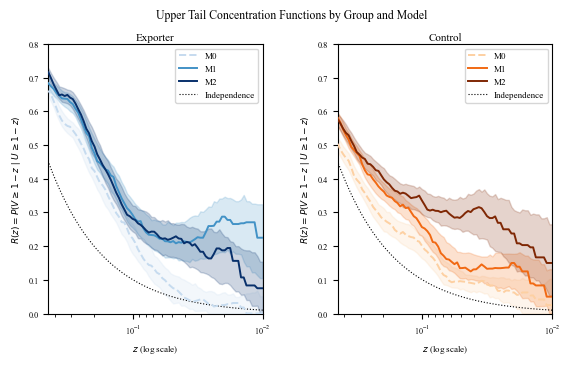

In [59]:
from scipy.stats import rankdata

fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.5))
plt.subplots_adjust(wspace=0.35)

colors = {
    'Exporter': {'M0': '#c6dbef', 'M1': '#4292c6', 'M2': '#08306b'},
    'Control':  {'M0': '#fdd0a2', 'M1': '#f16913', 'M2': '#7f2704'}
}
styles = {'M0': '--', 'M1': '-', 'M2': '-'}
z_grid = np.logspace(-2, np.log10(0.45), 80)
N_BOOT = 200

def compute_R(u, v, z_grid):
    return np.array([
        np.mean((u >= 1-z) & (v >= 1-z)) / np.mean(u >= 1-z)
        for z in z_grid
    ])

for i, (group_name, countries) in enumerate(groups.items()):
    ax = axes[i]

    for model in models:
        # point estimate
        u, v, _ = fits_store[(group_name, model)]
        R_point = compute_R(u, v, z_grid)

        # bootstrap bands
        dd_col = DD_COLS[model]
        country_arrays = []
        for country in countries:
            sub = df[df[COUNTRY_COL]==country][[CDS_COL, dd_col]].dropna()
            if len(sub) >= 10:
                country_arrays.append(sub.values)

        np.random.seed(42)
        boot_R = []
        for _ in range(N_BOOT):
            u_all, v_all = [], []
            for arr in country_arrays:
                idx  = np.random.choice(len(arr), len(arr), replace=True)
                boot = arr[idx]
                n    = len(boot)
                u_all.append(rankdata(boot[:,0]) / (n+1))
                v_all.append(rankdata(-boot[:,1]) / (n+1))
            u_pool = np.concatenate(u_all)
            v_pool = np.concatenate(v_all)
            boot_R.append(compute_R(u_pool, v_pool, z_grid))

        boot_R  = np.array(boot_R)
        R_low   = np.percentile(boot_R, 2.5,  axis=0)
        R_high  = np.percentile(boot_R, 97.5, axis=0)
        color   = colors[group_name][model]

        ax.plot(z_grid, R_point, color=color, linestyle=styles[model],
                linewidth=1.4, label=model, zorder=3)
        ax.fill_between(z_grid, R_low, R_high, color=color,
                        alpha=0.2, zorder=2)

    ax.plot(z_grid, z_grid, 'k:', linewidth=0.8, label='Independence')
    ax.set_xscale('log')
    ax.set_title(group_name, fontsize=8, pad=3)
    ax.set_xlabel(r'$z$ (log scale)', fontsize=6.5)
    ax.set_ylabel(r'$R(z) = P(V \geq 1-z \mid U \geq 1-z)$', fontsize=6.5)
    ax.legend(fontsize=6.5, framealpha=0.8)
    ax.set_xlim(0.45, z_grid[0])
    ax.set_ylim(0, 0.8)
    ax.tick_params(labelsize=6)

fig.suptitle('Upper Tail Concentration Functions by Group and Model',
             fontsize=8.5, fontweight='normal')

plt.show()

In [57]:
boot_results_theta = []
N_BOOT = 500
def fit_gumbel_fast(u, v):
    res = minimize_scalar(lambda th: -gumbel_loglik(u, v, th),
                          bounds=(1.001, 20), method='bounded')
    return res.x


for group_name, countries in groups.items():
    for model in models:
        dd_col = DD_COLS[model]
        country_arrays = []
        for country in countries:
            sub = df[df[COUNTRY_COL]==country][[CDS_COL, dd_col]].dropna()
            if len(sub) >= 10:
                country_arrays.append(sub.values)

        np.random.seed(42)
        boot_thetas = []
        for _ in range(N_BOOT):
            u_all, v_all = [], []
            for arr in country_arrays:
                idx  = np.random.choice(len(arr), len(arr), replace=True)
                boot = arr[idx]
                n    = len(boot)
                u_all.append(rankdata(boot[:,0]) / (n+1))
                v_all.append(rankdata(-boot[:,1]) / (n+1))
            try:
                theta = fit_gumbel_fast(np.concatenate(u_all), np.concatenate(v_all))
                boot_thetas.append(theta)
            except:
                continue

        boot_thetas = np.array(boot_thetas)
        boot_results_theta.append({
            'Group':  group_name, 'Model': model,
            'theta':  round(boot_thetas.mean(), 3),
            'p025':   round(np.percentile(boot_thetas, 2.5), 3),
            'p975':   round(np.percentile(boot_thetas, 97.5), 3)
        })

boot_theta_df = pd.DataFrame(boot_results_theta)
print(boot_theta_df.to_string(index=False))

   Group Model  theta  p025  p975
Exporter    M0  1.752 1.730 1.779
Exporter    M1  1.865 1.834 1.901
Exporter    M2  1.930 1.897 1.964
 Control    M0  1.513 1.498 1.528
 Control    M1  1.602 1.582 1.621
 Control    M2  1.648 1.626 1.668


In [58]:
def empirical_upper_tail_dep(u, v, z_low=0.01, z_high=0.10, n_grid=100):
    z_grid = np.linspace(z_low, z_high, n_grid)
    R = np.array([
        np.mean((u >= 1-z) & (v >= 1-z)) / np.mean(u >= 1-z)
        for z in z_grid
    ])
    return R.mean()

boot_tcf = []

for group_name, countries in groups.items():
    for model in models:
        dd_col = DD_COLS[model]
        country_arrays = []
        for country in countries:
            sub = df[df[COUNTRY_COL]==country][[CDS_COL, dd_col]].dropna()
            if len(sub) >= 10:
                country_arrays.append(sub.values)

        np.random.seed(42)
        boot_lams = []
        for _ in range(N_BOOT):
            u_all, v_all = [], []
            for arr in country_arrays:
                idx  = np.random.choice(len(arr), len(arr), replace=True)
                boot = arr[idx]
                n    = len(boot)
                u_all.append(rankdata(boot[:,0]) / (n+1))
                v_all.append(rankdata(-boot[:,1]) / (n+1))
            u_pool = np.concatenate(u_all)
            v_pool = np.concatenate(v_all)
            boot_lams.append(empirical_upper_tail_dep(u_pool, v_pool))

        boot_lams = np.array(boot_lams)
        boot_tcf.append({
            'Group':  group_name, 'Model': model,
            'R_bar':  round(boot_lams.mean(), 3),
            'p025':   round(np.percentile(boot_lams, 2.5), 3),
            'p975':   round(np.percentile(boot_lams, 97.5), 3)
        })

tcf_df = pd.DataFrame(boot_tcf)
print(tcf_df.to_string(index=False))

   Group Model  R_bar  p025  p975
Exporter    M0  0.100 0.072 0.127
Exporter    M1  0.240 0.201 0.279
Exporter    M2  0.217 0.181 0.249
 Control    M0  0.113 0.096 0.131
 Control    M1  0.167 0.139 0.192
 Control    M2  0.287 0.249 0.322
